# Belle 2014 — D⁰ → Kₛ⁰π⁺π⁻ dependente do tempo

Reconstrução do **modelo completo em componentes** da Tabela I de
[Belle, PRD 89, 091103 (2014), arXiv:1404.2412](https://arxiv.org/abs/1404.2412).
Inclui 12 ondas P/D, duas ondas S Kπ e a onda S ππ K-matrix.

**Status: reprodução em validação, não resultado experimental reproduzido.**
As magnitudes/fases e os parâmetros S-wave publicados são transcritos abaixo;
raios, massas/larguras não listadas e convenções angulares têm escolhas explícitas.
As fit fractions são comparadas sem reajustar coeficientes para forçar concordância.
Os testes temporais e o fit Asimov verificam a implementação local; não validam
por si só a equivalência de todas as funções de amplitude ao código Belle.
Não há dados Belle, eficiência, background ou resolução experimental neste notebook.

Referências adicionais: [BABAR 2010 e suplemento](https://arxiv.org/html/1004.5053)
para a fórmula Kπ **corrigida** e [BABAR 2008](https://arxiv.org/html/0804.2089)
para a K-matrix e as convenções herdadas. Não substituir a S-wave por `LASS()`:
a parametrização de produção tem fases adicionais e effective range negativo.

In [1]:
import os
import sys
from pathlib import Path
from dataclasses import dataclass, replace
os.environ["JAX_PLATFORMS"] = "cpu" # cpu, cuda, tpu

for root in (Path.cwd(), *Path.cwd().parents):
    if (root / "src" / "dalitzplotfitter").is_dir():
        sys.path.insert(0, str(root / "src"))
        break

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
pd.set_option("display.max_columns", None)
from dalitzplotfitter import (
    DecayChannel, DecayModel, KMatrix, Minimizer,
    NeutralMesonMixing, Parameter, PhaseSpaceSample, RealImag,
    RelativisticBreitWigner, Resonance, SquareDalitzGrid,
    TimeDependentDalitzNLL, TimeDependentFitSession, ZemachP, plot_contour,
)
from dalitzplotfitter.dynamics.lineshape.common import breakup_momentum

GRID_RESOLUTION = int(os.environ.get("BELLE_GRID_RESOLUTION", "300"))
TIME_ORDER = 48
TIME_MAX_PS = 4.0
ASIMOV_EVENTS = 100_000
TRUTH = {"mix.x": 0.0056, "mix.y": 0.0030}
TAU_PS = 0.4103
CHANNEL = DecayChannel("D0", ("K(S)0", "pi+", "pi-"))
print("JAX:", jax.default_backend(), "x64:", jax.config.x64_enabled)
print("massas [GeV]:", CHANNEL.parent_mass, CHANNEL.daughter_masses)

JAX: cpu x64: True
massas [GeV]: 1.8648399999999998 (0.49761099999999997, 0.13957039000000002, 0.13957039000000002)


## Entradas publicadas e escolhas ainda a auditar

Tabela I: magnitudes, fases em graus e FF em fração (não porcentagem).
K*(892) e Kπ S-wave usam as massas/larguras da tabela. Demais massas/larguras
abaixo são valores de trabalho explícitos; **não são transcrições certificadas do
conjunto PDG 2012 usado no Belle**. Os raios 1,5 GeV⁻¹ são herdados do BABAR 2008,
pendentes de confirmação para Belle. Usamos RBW para todas as ondas P/D conforme
o texto Belle e ZemachP; a ordem dos pares fixa o sinal angular.

Sem normalização individual, sem folding e sem CP direto. Não há coeficiente
externo adicional multiplicando a K-matrix: os coeficientes de produção já estão
na escala da tabela.

In [2]:
# name, pair, spin, magnitude, phase_deg, mass_GeV, width_GeV, FF_Belle
SPECS = [
    ("Kstar892_minus", (0, 2), 1, 1.590, 131.8, .89368, .04749, .6045),
    ("K0star1430_minus", (0, 2), 0, 2.059, -194.6, 1.4617, .2683, .0702),
    ("K2star1430_minus", (0, 2), 2, 1.150, -41.5, 1.4256, .0985, .0221),
    ("Kstar1410_minus", (0, 2), 1, .496, 83.4, 1.414, .232, .0026),
    ("Kstar1680_minus", (0, 2), 1, 1.556, -83.2, 1.717, .322, .0016),
    ("Kstar892_plus", (0, 1), 1, .139, -42.1, .89368, .04749, .0046),
    ("K0star1430_plus", (0, 1), 0, .176, -102.3, 1.4617, .2683, .0005),
    ("K2star1430_plus", (0, 1), 2, .077, -32.2, 1.4256, .0985, .0001),
    ("Kstar1410_plus", (0, 1), 1, .248, -145.7, 1.414, .232, .0007),
    ("Kstar1680_plus", (0, 1), 1, 1.407, 86.1, 1.717, .322, .0013),
    ("rho770", (1, 2), 1, 1., 0., .77526, .1491, .2000),
    ("omega782", (1, 2), 1, .0370, 114.9, .78265, .00849, .0057),
    ("f2_1270", (1, 2), 2, 1.300, -31.6, 1.2755, .1867, .0141),
    ("rho1450", (1, 2), 1, .532, 80.8, 1.465, .400, .0012),
]
REFERENCE_FF = {row[0]: row[-1] for row in SPECS}
REFERENCE_FF["pipi_S"] = .1288
BARRIER_RADIUS = 1.5

def polar(magnitude, phase_deg):
    return magnitude * np.exp(1j * np.deg2rad(phase_deg))

def coefficient(magnitude, phase_deg):
    z = polar(magnitude, phase_deg)
    return RealImag(z.real, z.imag)

display(pd.DataFrame(SPECS, columns=[
    "component", "pair", "spin", "magnitude", "phase_deg", "mass", "width", "FF_Belle"
]))

,component,pair,spin,magnitude,phase_deg,mass,width,FF_Belle
0,Kstar892_minus,"(0, 2)",1,1.590,131.8,0.89368,0.04749,0.6045
1,K0star1430_minus,"(0, 2)",0,2.059,-194.6,1.46170,0.26830,0.0702
2,K2star1430_minus,"(0, 2)",2,1.150,-41.5,1.42560,0.09850,0.0221
3,Kstar1410_minus,"(0, 2)",1,0.496,83.4,1.41400,0.23200,0.0026
4,Kstar1680_minus,"(0, 2)",1,1.556,-83.2,1.71700,0.32200,0.0016
5,Kstar892_plus,"(0, 1)",1,0.139,-42.1,0.89368,0.04749,0.0046
6,K0star1430_plus,"(0, 1)",0,0.176,-102.3,1.46170,0.26830,0.0005
7,K2star1430_plus,"(0, 1)",2,0.077,-32.2,1.42560,0.09850,0.0001
8,Kstar1410_plus,"(0, 1)",1,0.248,-145.7,1.41400,0.23200,0.0007
9,Kstar1680_plus,"(0, 1)",1,1.407,86.1,1.71700,0.32200,0.0013


## Kπ S-wave de produção

Implementação local da fórmula corrigida no suplemento BABAR 2010:
\(A=(m/q)[F\sin(\delta_F+\phi_F)e^{i(\delta_F+\phi_F)}+
R\sin\delta_R e^{i(\delta_R+\phi_R)}e^{2i(\delta_F+\phi_F)}]\).
Os parâmetros são os do Belle. `atan2` mantém o ramo contínuo da fase ressonante.
Não existe cutoff arbitrário em massa. A fórmula pode divergir no limiar quando
\(\phi_F
e0\); a quadratura usa pontos interiores, nunca o limiar exato.

In [3]:
@dataclass(frozen=True)
class EffectiveRangeProduction:
    F: float = .4524
    phi_F: float = .248
    R: float = 1.0
    phi_R: float = 2.495
    a: float = .172
    r: float = -20.6

    def __call__(self, mass, context):
        m = jnp.asarray(mass)
        m0, gamma0 = context.pole_mass, context.pole_width
        m1, m2 = context.daughter_masses
        q = breakup_momentum(m, m1, m2)
        q0 = breakup_momentum(jnp.asarray(m0), m1, m2)
        # Valid on the open physical mass interval; do not silently clip q at threshold.
        delta_F = jnp.arctan2(self.a * q, 1 + .5 * self.a * self.r * q**2)
        gamma = gamma0 * (q / q0) * (m0 / m)
        delta_R = jnp.arctan2(m0 * gamma, m0**2 - m**2)
        phase_F = delta_F + self.phi_F
        nonresonant = self.F * jnp.sin(phase_F) * jnp.exp(1j * phase_F)
        resonant = self.R * jnp.sin(delta_R) * jnp.exp(1j * (delta_R + self.phi_R + 2*phase_F))
        return m / q * (nonresonant + resonant)

KPI_SWAVE = EffectiveRangeProduction()
# P-vector: absent beta5/f14/f15 fixed to zero following the BABAR supplement.
# s0_prod is inherited from that supplement, not KMatrix's default -3.0.
PIPI_SWAVE = KMatrix(
    betas=tuple(polar(m, p) for m, p in [(4.23,164.),(10.90,15.6),(37.4,3.3),(14.7,-8.9)]) + (0j,),
    f_prod=tuple(polar(m, p) for m, p in [(12.76,-161.1),(14.2,-176.2),(10.0,-124.7)]) + (0j,0j),
    s0_prod=-3.92637,
)

In [4]:
resonances = [
    Resonance(name, pair, coefficient(mag, phase),
              lineshape=KPI_SWAVE if spin == 0 else RelativisticBreitWigner(),
              angular=ZemachP(), mass=mass, width=width, spin=spin,
              resonance_radius=BARRIER_RADIUS, parent_radius=BARRIER_RADIUS,
              normalize_component=False)
    for name, pair, spin, mag, phase, mass, width, _ in SPECS
]
resonances.append(Resonance(
    "pipi_S", (1,2), RealImag(1,0), lineshape=PIPI_SWAVE, angular=ZemachP(),
    mass=1., width=0., spin=0, normalize_component=False,
))
# `model` uses the default (gauss-legendre) normalization and is reused below
# by generate_toy(); TimeDependentFitSession derives Abar(s12,s13)=A(s13,s12)
# automatically (no-direct-CPV convention) instead of the hand-rolled
# ReflectedAmplitude/ABAR_COMPONENTS this notebook used to build manually.
model = DecayModel(CHANNEL, resonances, normalize_components=False)
A_COMPONENTS = tuple(model.amplitude_model.components)

def build_session(resolution):
    # A second DecayModel sharing the same `resonances` (identical dynamics
    # and coefficients as `model`) but with the explicit SquareDalitzGrid as
    # its normalization_sample, matching the manual cache this notebook used
    # to build with PreparedAmplitudeCache.prepare(..., data=grid.as_dict(),
    # normalization_data=grid.as_dict()) directly. Kept separate from `model`
    # so generate_toy()'s own default-normalization envelope is untouched.
    grid = SquareDalitzGrid(CHANNEL.parent_mass, CHANNEL.daughter_masses,
                           resolution=resolution, pair=(1,2)).sample()
    grid_model = DecayModel(CHANNEL, resonances, normalize_components=False,
                            normalization_sample=grid)
    # times/tags are unused placeholders: this section only reaches into
    # session.cache/session.n_particle_components for the FF audit and Dalitz
    # plot below, never session.base_objective/.fit() -- the Asimov section
    # further down builds its own session with real weighted pseudo-times.
    session = TimeDependentFitSession(
        grid_model, grid, times=jnp.zeros(grid.size), tags=jnp.ones(grid.size),
        mixing=NeutralMesonMixing(TRUTH["mix.x"], TRUTH["mix.y"], TAU_PS),
    )
    return grid, session

grid, session = build_session(GRID_RESOLUTION)
N_A = session.n_particle_components
GROUPS = jnp.stack((jnp.arange(2*N_A)<N_A, jnp.arange(2*N_A)>=N_A), axis=1)
assert N_A == 15
cache = session.cache
amplitudes, overlap = cache.coherent_groups({}, GROUPS)
assert np.isfinite(np.asarray(amplitudes)).all()
print("Componentes por sabor:", N_A, "pontos DP:", grid.size)
print("Overlap A/Abar:", np.asarray(overlap))

Componentes por sabor: 15 pontos DP: 90000
Overlap A/Abar: [[193.79860624+1.42108547e-14j  73.11863722+3.46389584e-14j]
 [ 73.11863722-3.73034936e-14j 193.79860624+0.00000000e+00j]]


## Auditoria das fit fractions e convergência

FFs de \(t=0\), sem aceitação, calculadas por \(c^\dagger Mc\).
A tabela Belle serve como alvo, não como condição de normalização.
Diferenças não são pulls: faltam covariâncias e equivalência certificada do modelo.
A coluna de convergência separa discretização de discrepância de convenção.
Aumente `GRID_RESOLUTION` para uma auditoria de precisão, especialmente no ω.

In [5]:
def fractions_and_total(prepared):
    matrix = prepared.normalization_matrix({})[:N_A, :N_A]
    coefficients = prepared.coefficient_vector({})[:N_A]
    total = jnp.real(jnp.vdot(coefficients, matrix @ coefficients))
    return np.asarray(jnp.abs(coefficients)**2 * jnp.real(jnp.diag(matrix)) / total), float(total)

ff, total = fractions_and_total(cache)
fine_grid, fine_session = build_session(2*GRID_RESOLUTION)
fine_cache = fine_session.cache
ff_fine, total_fine = fractions_and_total(fine_cache)
ff_table = pd.DataFrame({
    "component": [c.name for c in A_COMPONENTS],
    "FF local [%]": 100*ff,
    "FF grid 2x [%]": 100*ff_fine,
    "Belle [%]": [100*REFERENCE_FF[c.name] for c in A_COMPONENTS],
})
ff_table["local 2x - Belle [pp]"] = ff_table["FF grid 2x [%]"] - ff_table["Belle [%]"]
display(ff_table)
print("Mudança relativa da integral:", total_fine/total-1)
print("Máxima mudança FF [pp]:", 100*np.max(abs(ff_fine-ff)))
# Keep the finer grid for subsequent diagnostics and fit.
grid, cache = fine_grid, fine_cache
amplitudes, overlap = cache.coherent_groups({}, GROUPS)
del fine_grid, fine_cache, fine_session

,component,FF local [%],FF grid 2x [%],Belle [%],local 2x - Belle [pp]
0,Kstar892_minus,37.161420,37.140097,60.45,-23.309903
1,K0star1430_minus,12.254636,12.248265,7.02,5.228265
2,K2star1430_minus,0.228105,0.227974,2.21,-1.982026
3,Kstar1410_minus,0.157033,0.156943,0.26,-0.103057
4,Kstar1680_minus,0.214866,0.214743,0.16,0.054743
5,Kstar892_plus,0.284006,0.283843,0.46,-0.176157
6,K0star1430_plus,0.089539,0.089493,0.05,0.039493
7,K2star1430_plus,0.001023,0.001022,0.01,-0.008978
8,Kstar1410_plus,0.039258,0.039236,0.07,-0.030764
9,Kstar1680_plus,0.175686,0.175585,0.13,0.045585


Mudança relativa da integral: 0.0005741287832152775
Máxima mudança FF [pp]: 0.037193137766091365


INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m23: m0=0.782650 GeV, Gamma=8.490 MeV); using adaptive Gauss-Legendre normalization.


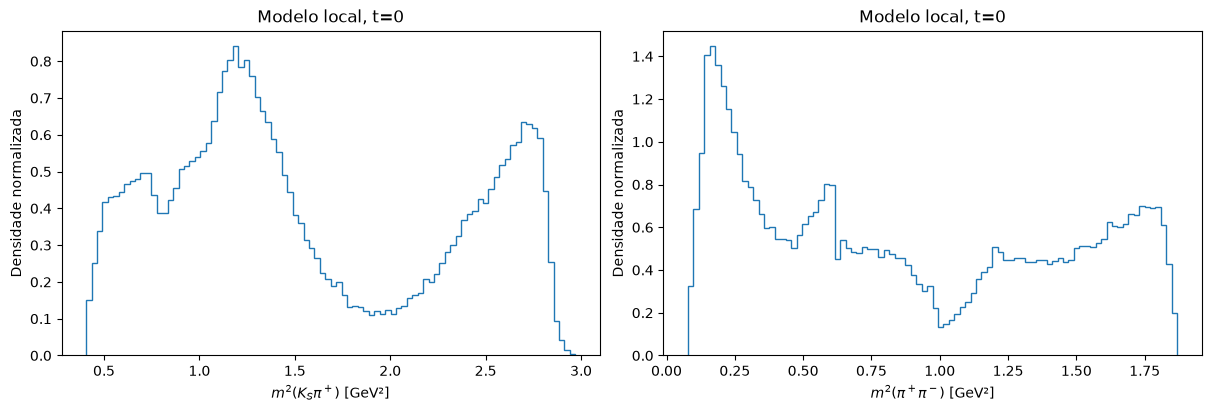

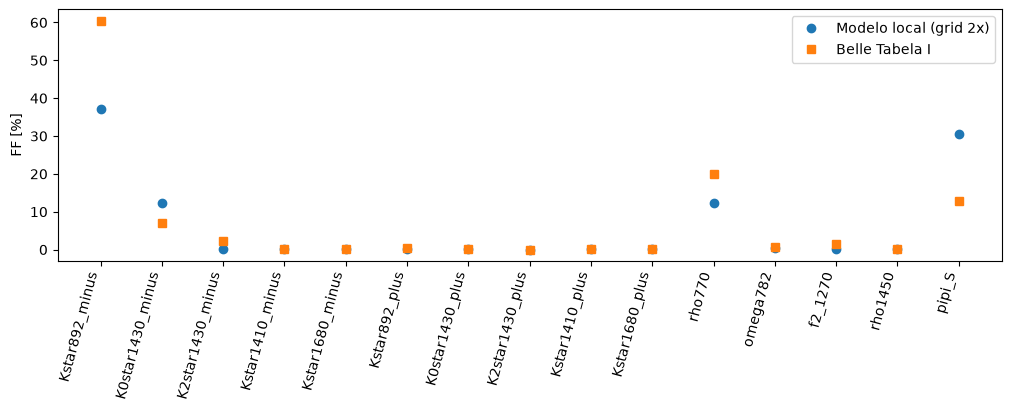

In [6]:
from dalitzplotfitter import generate_toy

# SquareDalitzGrid points are a fixed (m', theta') quadrature lattice, NOT an
# i.i.d. sample: histogramming them directly aliases against the bin edges
# (whole grid rows collapse into single s12/s23 values, producing a comb
# pattern). Draw a genuine random toy from the t=0 model instead and
# histogram that; residual bin-to-bin noise is then ordinary Poisson
# statistics, not a grid artifact. accept-reject is used here (not the
# default inverse-transform) as the slower, exact reference sampler,
# appropriate for a diagnostic plot rather than repeated large-N generation.
PROJECTION_TOY_SIZE = 100_000
projection_toy = generate_toy(
    model, PROJECTION_TOY_SIZE, method="accept-reject", seed=1, include_momenta=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12,4), constrained_layout=True)
for ax, key, title in zip(axes, ("s12", "s23"), (r"$m^2(K_S\pi^+)$", r"$m^2(\pi^+\pi^-)$")):
    ax.hist(np.asarray(getattr(projection_toy, key)), bins=90,
            histtype="step", density=True)
    ax.set(xlabel=title+" [GeV²]", ylabel="Densidade normalizada", title="Modelo local, t=0")
plt.show()
fig, ax = plt.subplots(figsize=(10,4), constrained_layout=True)
x = np.arange(N_A)
ax.plot(x, 100*ff_fine, "o", label="Modelo local (grid 2x)")
ax.plot(x, ff_table["Belle [%]"], "s", label="Belle Tabela I")
ax.set_xticks(x, ff_table.component, rotation=75, ha="right")
ax.set_ylabel("FF [%]"); ax.legend(); plt.show()

## Dalitz bidimensional do modelo

Densidade coerente em **t=0**, normalizada no Dalitz completo, para D⁰ e D̄⁰.
Sem folding, eficiência ou background. Os dois painéis usam a mesma escala
logarítmica; valores abaixo de 10⁻⁵ do máximo saturam na cor inferior.
A curva preta delimita a região física. Sem CP direto, os painéis se relacionam
pela troca dos eixos. São previsões do modelo local em auditoria, não dados Belle.


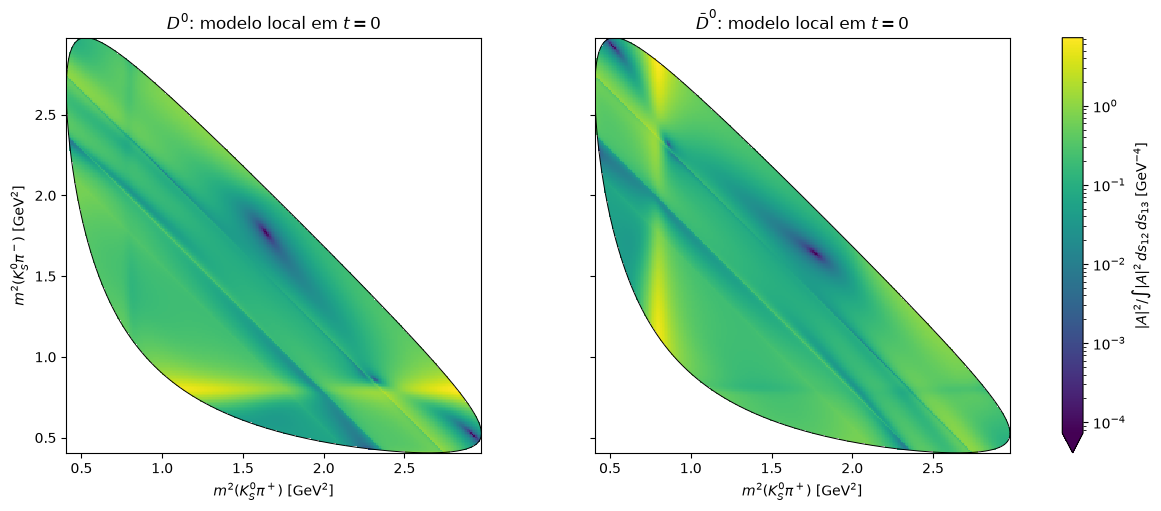

In [7]:
from matplotlib.colors import LogNorm
from dalitzplotfitter import dalitz_s13_limits

# Evaluate the intensity on a uniform invariant-mass-squared mesh.
# No quadrature weights here: pixel colour is PDF density, not grid occupancy.
DALITZ_PIXELS = 260
m1, m2, m3 = CHANNEL.daughter_masses
M = CHANNEL.parent_mass
s12_edges = np.linspace((m1+m2)**2, (M-m3)**2, DALITZ_PIXELS+1)
s13_edges = np.linspace((m1+m3)**2, (M-m2)**2, DALITZ_PIXELS+1)
s12_centers = (s12_edges[:-1]+s12_edges[1:])/2
s13_centers = (s13_edges[:-1]+s13_edges[1:])/2
xx, yy = np.meshgrid(s12_centers, s13_centers)
ylo, yhi = dalitz_s13_limits(jnp.asarray(xx), mother_mass=M,
                             masses=CHANNEL.daughter_masses)
physical = (yy > np.asarray(ylo)) & (yy < np.asarray(yhi))
plot_data = {
    "s12": jnp.asarray(xx[physical]),
    "s13": jnp.asarray(yy[physical]),
    "s23": jnp.asarray(M**2+m1**2+m2**2+m3**2-xx[physical]-yy[physical]),
}

def _coherent(data):
    amplitude = jnp.zeros(data["s12"].shape, dtype=jnp.complex128)
    for component in A_COMPONENTS:
        amplitude = amplitude + component.value(data)
    return amplitude

# No-direct-CPV convention (TimeDependentFitSession's default, used above):
# Abar(s12,s13) = A(s13,s12), so D0bar is just A_COMPONENTS evaluated on the
# swapped invariants -- no separate ABAR_COMPONENTS list needed here.
reflected_data = {"s12": plot_data["s13"], "s13": plot_data["s12"], "s23": plot_data["s23"]}
plot_amplitudes = [np.asarray(_coherent(plot_data)), np.asarray(_coherent(reflected_data))]

# Full coherent, t=0 normalization; no efficiency or backgrounds.
plot_overlap = np.asarray(cache.coherent_groups({}, GROUPS)[1])
dalitz_densities = []
for flavour, amplitude in enumerate(plot_amplitudes):
    density = np.full(xx.shape, np.nan)
    density[physical] = np.abs(amplitude)**2 / plot_overlap[flavour, flavour].real
    dalitz_densities.append(density)
assert all(np.isfinite(d[physical]).all() for d in dalitz_densities)
# No-direct-CPV model: reflected densities must agree on the symmetric mesh.
np.testing.assert_allclose(dalitz_densities[0], dalitz_densities[1].T,
                           rtol=1e-8, atol=1e-10, equal_nan=True)

vmax = max(np.nanmax(d) for d in dalitz_densities)
colour_norm = LogNorm(vmin=vmax*1e-5, vmax=vmax)
fig_dalitz, axes_dalitz = plt.subplots(1, 2, figsize=(12, 5),
                                      sharex=True, sharey=True, constrained_layout=True)
boundary_x = np.linspace(s12_edges[0], s12_edges[-1], 1000)
boundary_low, boundary_high = dalitz_s13_limits(
    jnp.asarray(boundary_x), mother_mass=M, masses=CHANNEL.daughter_masses)
for ax, density, label in zip(axes_dalitz, dalitz_densities, (r"$D^0$", r"$\bar D^0$")):
    mesh = ax.pcolormesh(s12_edges, s13_edges, np.ma.masked_invalid(density),
                         cmap="viridis", norm=colour_norm, shading="flat", rasterized=True)
    ax.plot(boundary_x, boundary_low, color="black", lw=.7)
    ax.plot(boundary_x, boundary_high, color="black", lw=.7)
    ax.set(xlabel=r"$m^2(K_S^0\pi^+)$ [GeV$^2$]",
           title=label+": modelo local em $t=0$")
    ax.set_aspect("equal")
axes_dalitz[0].set_ylabel(r"$m^2(K_S^0\pi^-)$ [GeV$^2$]")
fig_dalitz.colorbar(mesh, ax=axes_dalitz, extend="min",
                    label=r"$|A|^2 / \int |A|^2\,ds_{12}\,ds_{13}$ [GeV$^{-4}$]")
plt.show()


## Reprodução das equações temporais

Comparação pontual contra as equações publicadas, escritas independentemente em
NumPy. Inclui os dois sabores e q/p complexo. Este teste é independente da
concordância das fit fractions.

In [8]:
def paper_rate(t, a, b, x, y, tau, ratio=1+0j):
    u = np.asarray(t)/tau
    cross = ratio*np.asarray(b)*np.conj(a)
    return np.exp(-u)/2*(
        (abs(a)**2+abs(ratio*b)**2)*np.cosh(y*u)
        +(abs(a)**2-abs(ratio*b)**2)*np.cos(x*u)
        +2*cross.real*np.sinh(y*u)-2*cross.imag*np.sin(x*u))

probe_times = np.array([0., .1, .4, 1., 2.])
a, b = complex(amplitudes[grid.size//3,0]), complex(amplitudes[grid.size//3,1])
ratio = .9*np.exp(-1j*np.deg2rad(6.))
mixing_probe = NeutralMesonMixing(TRUTH["mix.x"], TRUTH["mix.y"], TAU_PS, .9, np.angle(ratio))
k = np.asarray(mixing_probe.basis(probe_times, {}))
for aa, bb, rr in [(a,b,ratio),(b,a,1/ratio)]:
    cross = rr*bb*np.conj(aa)
    actual = k[:,0]*abs(aa)**2+k[:,1]*abs(rr*bb)**2+2*(k[:,2]*cross.real-k[:,3]*cross.imag)
    expected = paper_rate(probe_times, aa, bb, *TRUTH.values(), TAU_PS, rr)
    np.testing.assert_allclose(actual, expected, rtol=1e-11, atol=1e-12)
print("Equações Belle (1–2): OK para ambos os sabores")

Equações Belle (1–2): OK para ambos os sabores


## Fit Asimov de x,y — fechamento do modelo local

Amplitudes fixas, CP conservado, aceitação unitária e resolução perfeita.
Pesos Asimov são gerados pelas equações NumPy, com medida DP × dt e normalização
separada por sabor. Ajustamos a partir de valores distintos da verdade.
O número equivalente de eventos controla a Hessiana, não transforma estes pontos
em dados experimentais. A distribuição discreta aproxima a integração contínua.

In [9]:
time_nodes, time_weights = np.polynomial.legendre.leggauss(TIME_ORDER)
time_nodes = TIME_MAX_PS*(time_nodes+1)/2
time_weights = TIME_MAX_PS*time_weights/2
# Bound memory for the Asimov example: use the original grid order, audited above.
asimov_grid, asimov_session = build_session(GRID_RESOLUTION)
asimov_base = asimov_session.cache
amp_asimov, _ = asimov_base.coherent_groups({}, GROUPS)
a, b = np.asarray(amp_asimov).T
measure = time_weights[:,None]*np.asarray(asimov_grid.weights)[None,:]/asimov_grid.size
probabilities = []
for aa, bb in ((a,b),(b,a)):
    rate = paper_rate(time_nodes[:,None], aa, bb, *TRUTH.values(), TAU_PS)
    p = rate*measure
    probabilities.append(.5*p/p.sum())
asimov_weights = jnp.asarray(ASIMOV_EVENTS*np.stack(probabilities).ravel())
tag_id, time_id, dp_id = np.indices((2, TIME_ORDER, asimov_grid.size)).reshape(3,-1)
asimov_cache = replace(asimov_base, data_components=asimov_base.data_components[dp_id])
x = Parameter("mix.x", .02, bounds=(-.1,.1), step=.001)
y = Parameter("mix.y", -.01, bounds=(-.1,.1), step=.001)
parameters = (x,y)
asimov_cache.check_parameters(parameters)
nll = TimeDependentDalitzNLL(
    asimov_cache, N_A, time_nodes[time_id], 1-2*tag_id,
    NeutralMesonMixing(x,y,TAU_PS), time_range=(0,TIME_MAX_PS),
)
def asimov_objective(values):
    return -jnp.sum(asimov_weights*jnp.log(nll.densities(values)))
result = Minimizer(asimov_objective, parameters).fit(strategy=1, hesse=True)
print(result.fmin)
closure = pd.DataFrame({
    "injetado": TRUTH,
    "ajustado": {p.name: result.values[p.name] for p in parameters},
    "erro Asimov ideal": {p.name: result.errors[p.name] for p in parameters},
})
display(closure)
assert result.valid
np.testing.assert_allclose(closure.ajustado, closure.injetado, atol=3e-6, rtol=0)

/home/juan-leite/Work/DalitzPlotFitter/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1333: UserWarning: A large amount of constants were captured during lowering (4.35GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.391e+04                  │         Nfcn = 42, Ngrad = 3         │
│ EDM = 3.59e-09 (Goal: 1e-07)     │           time = 98.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘


,injetado,ajustado,erro Asimov ideal
mix.x,0.0056,0.0056,0.003580
mix.y,0.0030,0.0030,0.003071


## Toy de eventos reais e `plot_time_projection`

O fit Asimov acima usa a verdade exata numa grade ponderada (sem ruído
estatístico). Esta célula reamostra um conjunto de eventos **discretos e
reais** a partir da mesma grade de pesos Asimov (reamostragem ponderada,
mesma técnica de `dalitzplotfitter.sampling.weighted_resample`, aplicada
aqui à grade (tag, tempo, DP) já construída acima), roda um fit não-binned
genuíno por evento via `TimeDependentFitSession.fit()` e usa
`session.plot_time_projection()` para sobrepor o histograma de tempo
observado (por tag) à curva exata integrada no Dalitz
(`TimeDependentDalitzNLL.dalitz_integrated_time_pdf`).

O tempo de cada evento vem de um dos `TIME_ORDER` nós de quadratura
Gauss-Legendre — não é uma geração contínua em tempo. Isso é suficiente para
demonstrar `plot_time_projection` com um fit real por evento, mas não é (e
não substitui) um gerador de toy contínuo em tempo; o pacote ainda não tem
um `generate_toy` com dimensão temporal.

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.235e+04                  │         Nfcn = 46, Ngrad = 3         │
│ EDM = 2.23e-12 (Goal: 1e-07)     │            time = 0.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
valid=True  NLL=12353.810746
parameter                           value            error


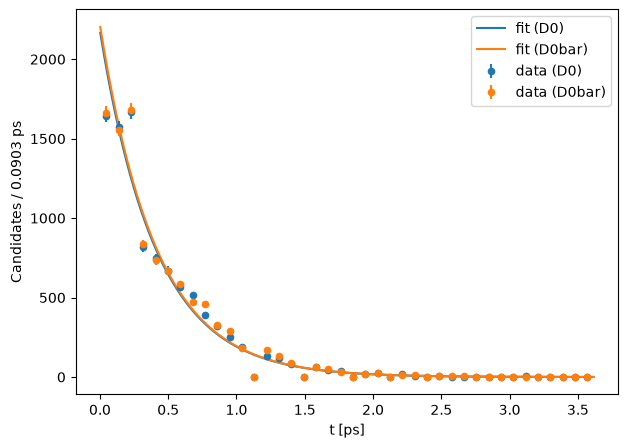

In [10]:
TOY_EVENTS = 20_000
rng = np.random.default_rng(7)
asimov_probabilities = np.asarray(asimov_weights) / float(np.sum(asimov_weights))
chosen = rng.choice(asimov_weights.size, size=TOY_EVENTS, p=asimov_probabilities)
toy_tag_id, toy_time_id, toy_dp_id = tag_id[chosen], time_id[chosen], dp_id[chosen]

toy_data = PhaseSpaceSample(
    s12=jnp.asarray(asimov_grid.s12)[toy_dp_id],
    s13=jnp.asarray(asimov_grid.s13)[toy_dp_id],
    s23=jnp.asarray(asimov_grid.s23)[toy_dp_id],
    weights=jnp.ones(TOY_EVENTS),
)
toy_session = TimeDependentFitSession(
    asimov_session.model, toy_data,
    jnp.asarray(time_nodes[toy_time_id]), jnp.asarray(1 - 2 * toy_tag_id),
    NeutralMesonMixing(
        Parameter("toy.mix.x", .02, bounds=(-.1, .1), step=.001),
        Parameter("toy.mix.y", -.01, bounds=(-.1, .1), step=.001),
        TAU_PS,
    ),
)
toy_result = toy_session.fit(strategy=1, hesse=True)
print(toy_result.fmin)
toy_session.print_result(toy_result)
assert toy_result.valid
toy_session.plot_time_projection(toy_result, bins=40, time_unit="ps")
plt.show()

## Contorno de confiança (x, y)

`plot_contour(result, "toy.mix.x", "toy.mix.y")` é o plot "manchete" desse
tipo de medida — a Fig. 4 do paper Belle mostra exatamente isso: o ponto de
melhor ajuste e os contornos de 68,3%/95%. `toy_result` (o fit real por
evento da célula acima) já tem só esses dois parâmetros soltos, então serve
direto. Os contornos vêm de `Minuit.mncontour` — verossimilhança de perfil
de verdade (reminimiza os outros parâmetros livres em cada ponto do scan),
não a aproximação gaussiana da elipse de covariância.

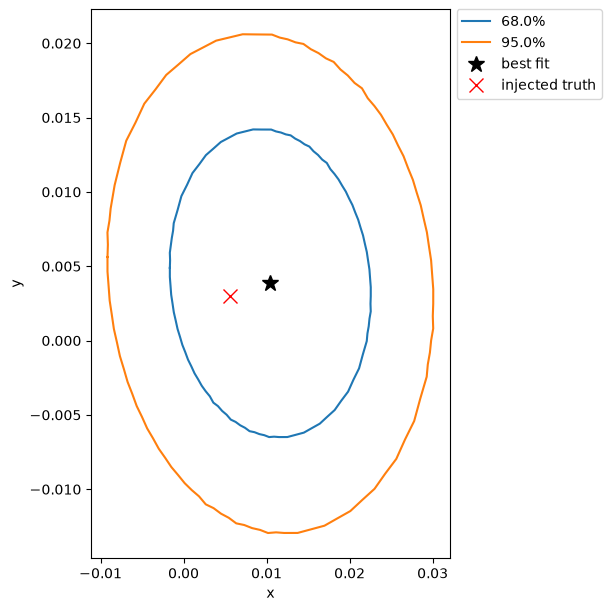

In [11]:
ax_contour = plot_contour(toy_result, "toy.mix.x", "toy.mix.y", cl=(0.68, 0.95))
ax_contour.plot(TRUTH["mix.x"], TRUTH["mix.y"], marker="x", color="red",
               markersize=10, linestyle="none", label="injected truth")
ax_contour.set_xlabel("x")
ax_contour.set_ylabel("y")
# Match plot_contour's own legend placement (outside the axes): calling
# .legend() again with no args here would fall back to matplotlib's "best"
# location, which tends to land back on top of the contours it labels.
ax_contour.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
plt.show()

## `plot_projection` — Dalitz por tag, integrado no tempo

`session.plot_projection(result, variable)` compara, para cada tag observada
(D⁰ | D̄⁰, um painel cada), o histograma de uma variável do Dalitz contra a
predição do modelo **integrada em tempo** sobre `time_range`
(`TimeDependentDalitzNLL.tag_marginal_density`) — diferente dos gráficos
anteriores (que são em `t=0` ou marginais em tempo). Usa o mesmo toy real
(`toy_session`, `toy_result`) da célula anterior.

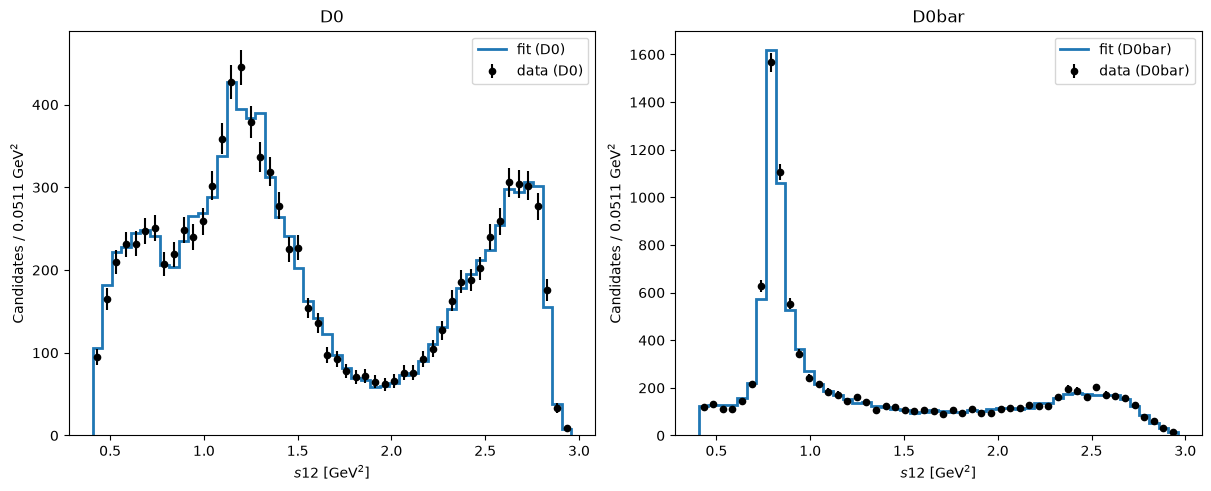

In [12]:
toy_session.plot_projection(toy_result, "s12", bins=50, projection_size=100_000)
plt.show()

## GIF: evolução da forma do Dalitz com t

`TimeDependentDalitzNLL.dalitz_density_at_time(A, Ā, t, params)` dá o
"snapshot" conjunto (Dalitz, tag) em um `t` fixo, normalizado para integrar a
1 no Dalitz **naquele mesmo `t`** — ou seja, remove o decaimento exponencial
trivial em `t` e isola só a **mudança de forma** do Dalitz causada pela
mistura (x faz o D⁰ oscilar pra D̄⁰; y faz os autoestados de massa decaírem
com taxas ligeiramente diferentes). Em `t=0` reduz exatamente a `|A|²/ia`
(mesma normalização da célula "Dalitz bidimensional" acima).

**Aviso:** os valores reais de x,y do Belle (~0,56% e ~0,30%) tornam essa
mudança de forma imperceptível a olho nu numa janela de tempo realista — o
período de oscilação de x sozinho é ~460 ps, muito maior que os poucos ps
observados; é exatamente por isso que essa medida exige estatística enorme.
Para a animação abaixo, x e y são **exagerados de propósito** só para tornar
o efeito qualitativo visível — não é uma alegação sobre os valores físicos
ou o resultado do fit.

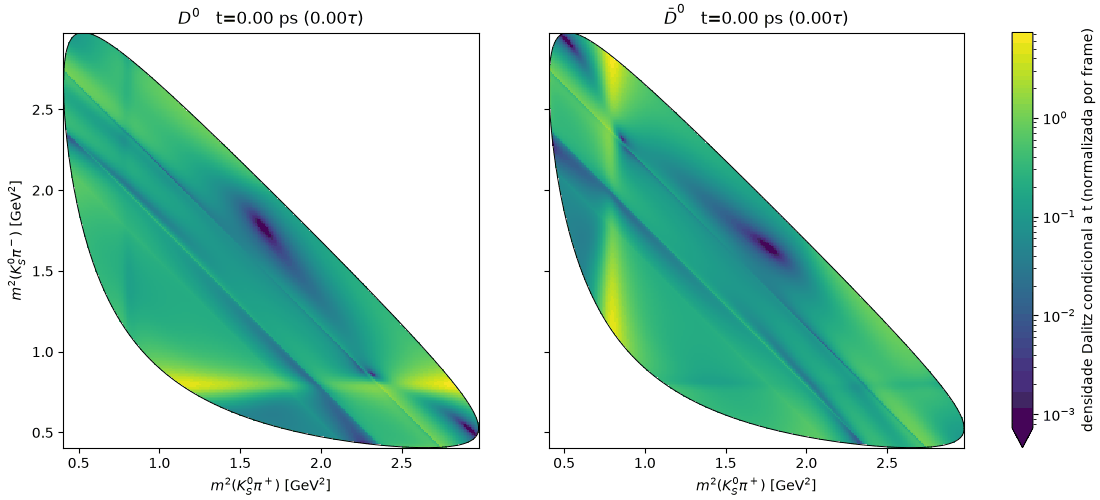

In [13]:
import tempfile

from IPython.display import Image, display
from matplotlib.animation import FuncAnimation, PillowWriter

# Illustration only -- see markdown above: NOT the physical/fitted x,y.
DEMO_MIXING = NeutralMesonMixing(0.6, 0.35, TAU_PS)
ANIMATION_TIMES = np.linspace(0.0, 5 * TAU_PS, 48)

# Reuses cache/N_A/GROUPS (the fine grid from the FF audit above) and
# plot_amplitudes/xx/physical/... (the uniform mesh from "Dalitz bidimensional
# do modelo" above); only the mixing kernel is swapped for the demo one.
# times/tags are unused placeholders, same convention as build_session().
demo_nll = TimeDependentDalitzNLL(
    cache, N_A, jnp.zeros(grid.size), jnp.ones(grid.size), DEMO_MIXING,
)

frames_plus, frames_minus = [], []
for t in ANIMATION_TIMES:
    dp, dm = demo_nll.dalitz_density_at_time(
        jnp.asarray(plot_amplitudes[0]), jnp.asarray(plot_amplitudes[1]), float(t), {},
    )
    density_plus = np.full(xx.shape, np.nan)
    density_plus[physical] = np.asarray(dp)
    density_minus = np.full(xx.shape, np.nan)
    density_minus[physical] = np.asarray(dm)
    frames_plus.append(density_plus)
    frames_minus.append(density_minus)

# Fixed colour scale across all frames: since each frame is independently
# normalized to integrate to 1 over the Dalitz plane, a fixed scale means
# brightness stays comparable frame to frame, and only the SHAPE moves.
anim_vmax = max(np.nanmax(f) for f in frames_plus + frames_minus)
anim_norm = LogNorm(vmin=anim_vmax * 1e-4, vmax=anim_vmax)
anim_mappable = plt.cm.ScalarMappable(norm=anim_norm, cmap="viridis")

fig_anim, axes_anim = plt.subplots(
    1, 2, figsize=(11, 5), sharex=True, sharey=True, constrained_layout=True,
)
fig_anim.colorbar(
    anim_mappable, ax=axes_anim, extend="min",
    label="densidade Dalitz condicional a t (normalizada por frame)",
)

def draw_frame(i):
    for ax, frame, label in zip(
        axes_anim, (frames_plus[i], frames_minus[i]), (r"$D^0$", r"$\bar D^0$"),
        strict=True,
    ):
        ax.clear()
        ax.pcolormesh(s12_edges, s13_edges, np.ma.masked_invalid(frame),
                     cmap="viridis", norm=anim_norm, shading="flat", rasterized=True)
        ax.plot(boundary_x, boundary_low, color="black", lw=.7)
        ax.plot(boundary_x, boundary_high, color="black", lw=.7)
        t_ps, t_tau = ANIMATION_TIMES[i], ANIMATION_TIMES[i] / TAU_PS
        ax.set_title(f"{label}   t={t_ps:.2f} ps ({t_tau:.2f}" + r"$\tau$)")
        ax.set_xlabel(r"$m^2(K_S^0\pi^+)$ [GeV$^2$]")
        ax.set_aspect("equal")
    axes_anim[0].set_ylabel(r"$m^2(K_S^0\pi^-)$ [GeV$^2$]")
    return axes_anim

anim = FuncAnimation(fig_anim, draw_frame, frames=len(ANIMATION_TIMES), interval=120)
with tempfile.NamedTemporaryFile(suffix=".gif") as tmp:
    anim.save(tmp.name, writer=PillowWriter(fps=8))
    tmp.seek(0)
    gif_bytes = tmp.read()
plt.close(fig_anim)
display(Image(data=gif_bytes, format="gif"))

## Discrepância ainda aberta

Na execução CPU com grades 80 e 160, obtivemos na grade mais fina:

| Componente | Local [%] | Belle [%] |
|---|---:|---:|
| K*(892)− | 37,118 | 60,45 |
| ρ(770) | 12,395 | 20,00 |
| ππ S-wave | 30,487 | 12,88 |
| K₂*(1430)− | 0,228 | 2,21 |

A integral mudou aproximadamente −0,18% entre as grades; a maior mudança de FF
foi 0,30 ponto percentual. Essas mudanças **não demonstram convergência completa**,
mas são muito menores que as discrepâncias principais. As convenções de escala
por spin, barreiras e S-waves precisam de auditoria antes de chamar este modelo
de reprodução numérica do Belle. Os coeficientes publicados foram preservados.


## O que falta para fechar a reprodução Belle

1. Confirmar massas/larguras PDG 2012, raios e fatores angulares/barreiras do código
   Belle, usando a tabela de FF acima como diagnóstico.
2. Confirmar `s0_prod`, tratamento 4π e limiares da K-matrix e parâmetros fixos
   herdados; os polos/couplings do pacote coincidem com a tabela BABAR 2008,
   mas isso não certifica cada convenção numérica.
3. Investigar discrepâncias persistentes de FF antes de interpretar uma curva
   como reprodução publicada; não reescalar componentes para escondê-las.
4. Para o fit experimental: dados, eficiência no DP, resolução temporal por
   configuração do detector e backgrounds. Este notebook não inventa esses inputs.

O núcleo suporta aceitação temporal fatorizada e resolução gaussiana via
quadratura (ver `docs/time_dependent.md`), mas uma gaussiana arbitrária não
reproduz a mistura de gaussianas ajustada pelo Belle.

## Validação com eficiência e background

Esta cópia adiciona uma validação da API time-dependent com uma eficiência Dalitz e um background fatorizado. Como o notebook Belle não contém mapas experimentais de seleção, as formas abaixo são artificiais e servem apenas para exercitar o fluxo:

- a eficiência é aplicada ao sinal no Dalitz e entra na normalização do sinal;
- o background tem sua própria forma Dalitz já selecionada;
- o background tem uma PDF temporal exponencial truncada e normalizada em `time_range`;
- a fração de sinal é condicional e não é um yield estendido.

Isto valida a composição da likelihood, não uma reprodução dos backgrounds do Belle.

backend: cpu
events: 1700 parameters: ['demo.mix.x', 'demo.mix.y', 'demo.signal_fraction']
mixture NLL at start: 2177.4017551798033
[Minimizer] single fit with 3 free parameters (method=minuit, simplex=False, strategy=1, hesse=False, hessian=numerical, ncall=80, tolerance=0.0001)
[Minimizer] MIGRAD 1 started
[Minimizer] MIGRAD 1 finished in 0.700 s: nfcn=+50, ngrad=+4, nhessian=+0
[Minimizer] single fit finished: valid=True  NLL=2176.290889  EDM=1.016e-08  nfcn=50
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2176                       │         Nfcn = 50, Ngrad = 4         │
│ EDM = 1.02e-08 (Goal: 1e-07)     │            time = 0.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │

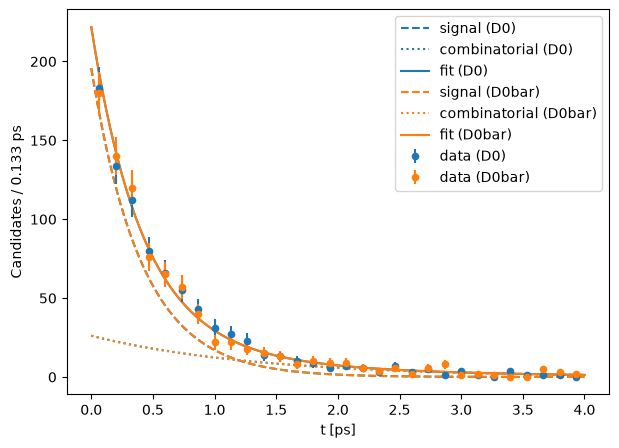

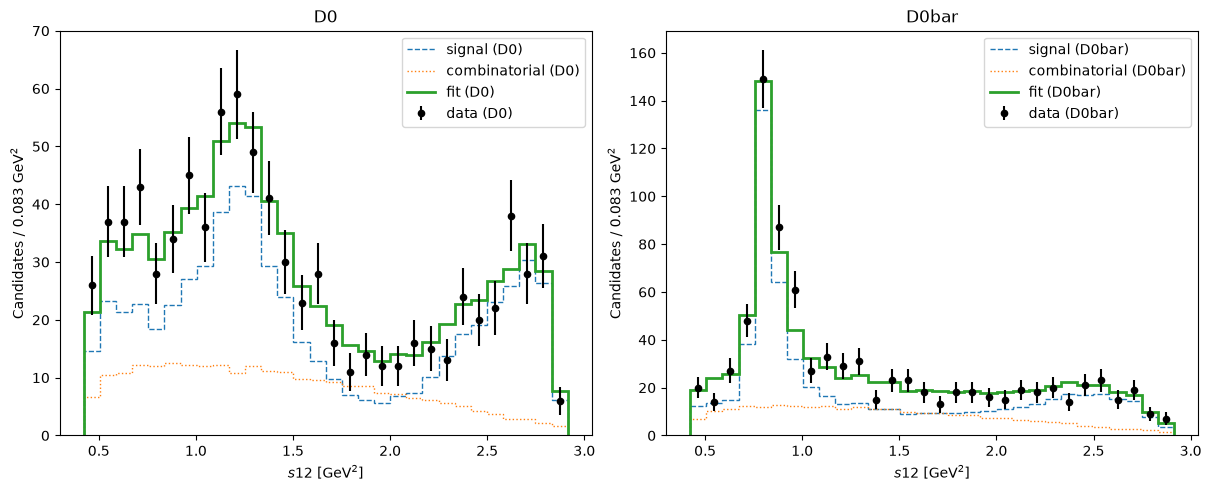

In [20]:
from dalitzplotfitter import ToyBackground, generate_signal_toy, generate_toy

DEMO_TIME_RANGE = (0.0, TIME_MAX_PS)
DEMO_SIZE_SIGNAL_PER_TAG = 600
DEMO_SIZE_BACKGROUND_PER_TAG = 250


def demo_efficiency(data):
    """Artificial symmetric Dalitz efficiency used only for API validation."""
    value = 0.78 + 0.10 * jnp.sin(1.7 * (data["s12"] + data["s13"]))
    return jnp.clip(value, 0.35, 0.98)


def demo_background_shape(data):
    """Artificial selected background shape; it is not a Belle map."""
    return 1.0 + 0.25 * jnp.cos(0.8 * data["s12"]) + 0.15 * jnp.sin(0.6 * data["s13"])


def reflected_sample(sample):
    return PhaseSpaceSample(
        s12=sample.s13,
        s13=sample.s12,
        s23=sample.s23,
        weights=sample.weights,
    )


def truncated_exponential(t, rate, low, high):
    norm = jnp.exp(-rate * low) - jnp.exp(-rate * high)
    return jnp.where(
        (t >= low) & (t <= high),
        rate * jnp.exp(-rate * t) / norm,
        0.0,
    )


# A signal sample generated with `model` has the D0 spatial density. In the
# no-direct-CPV convention used by this notebook, D0bar is its s12/s13 reflection.
# accept-reject is used here because it evaluates this Belle model's density
# directly; the inverse-transform sampler is not part of this validation.
signal_plus = generate_signal_toy(
    model,
    DEMO_SIZE_SIGNAL_PER_TAG,
    efficiency=demo_efficiency,
    seed=20140911,
    method="accept-reject",
    pool_size=10_000,
    include_momenta=False,
)
signal_minus = reflected_sample(generate_signal_toy(
    model,
    DEMO_SIZE_SIGNAL_PER_TAG,
    efficiency=demo_efficiency,
    seed=20140914,
    method="accept-reject",
    pool_size=10_000,
    include_momenta=False,
))

background_plus = generate_toy(
    model,
    DEMO_SIZE_BACKGROUND_PER_TAG,
    signal_fraction=0.0,
    backgrounds=(ToyBackground("combinatorial", demo_background_shape),),
    seed=20140912,
    method="accept-reject",
    pool_size=10_000,
    include_momenta=False,
)
background_minus = generate_toy(
    model,
    DEMO_SIZE_BACKGROUND_PER_TAG,
    signal_fraction=0.0,
    backgrounds=(ToyBackground("combinatorial", demo_background_shape),),
    seed=20140915,
    method="accept-reject",
    pool_size=10_000,
    include_momenta=False,
)

rng = np.random.default_rng(20140913)
def sample_time(size, rate):
    u = rng.uniform(size=size)
    low, high = DEMO_TIME_RANGE
    return -np.log(np.exp(-rate * low) - u * (np.exp(-rate * low) - np.exp(-rate * high))) / rate


def assemble_samples(*samples):
    return PhaseSpaceSample(
        s12=jnp.concatenate(tuple(sample.s12 for sample in samples)),
        s13=jnp.concatenate(tuple(sample.s13 for sample in samples)),
        s23=jnp.concatenate(tuple(sample.s23 for sample in samples)),
        weights=jnp.ones(sum(sample.size for sample in samples)),
    )


demo_data = assemble_samples(signal_plus, signal_minus, background_plus, background_minus)
demo_times = jnp.asarray(np.concatenate((
    sample_time(signal_plus.size, 1.0 / TAU_PS),
    sample_time(signal_minus.size, 1.0 / TAU_PS),
    sample_time(background_plus.size, 0.75),
    sample_time(background_minus.size, 0.75),
)))
demo_tags = jnp.asarray(np.concatenate((
    np.ones(signal_plus.size, dtype=int),
    -np.ones(signal_minus.size, dtype=int),
    np.ones(background_plus.size, dtype=int),
    -np.ones(background_minus.size, dtype=int),
)))


def demo_background_time(data, parameters):
    return truncated_exponential(data["t"], 0.75, *DEMO_TIME_RANGE)


demo_session = TimeDependentFitSession(
    model,
    demo_data,
    demo_times,
    demo_tags,
    NeutralMesonMixing(
        Parameter("demo.mix.x", TRUTH["mix.x"], bounds=(-0.1, 0.1), step=0.001),
        Parameter("demo.mix.y", TRUTH["mix.y"], bounds=(-0.1, 0.1), step=0.001),
        TAU_PS,
    ),
    efficiency=demo_efficiency,
    time_range=DEMO_TIME_RANGE,
    signal_fraction=Parameter("demo.signal_fraction", 0.70, bounds=(0.0, 1.0)),
).with_background(
    "combinatorial",
    demo_background_shape,
    time_pdf=demo_background_time,
)

demo_values = {
    parameter.name: parameter.value
    for parameter in demo_session.parameters
    if not parameter.fixed
}
print("backend:", jax.default_backend())
print("events:", demo_data.size, "parameters:", sorted(demo_values))
print("mixture NLL at start:", float(demo_session.objective(demo_values)))

demo_result = demo_session.fit(
    start_values=demo_values,
    strategy=1,
    simplex=False,
    hesse=False,
    ncall=80,
    verbose=1,
)
print(demo_result.fmin)
demo_session.plot_time_projection(demo_result, bins=30, time_unit="ps")
plt.show()
demo_session.plot_projection(demo_result, "s12", bins=30, projection_size=20_000)
plt.show()